# Lot 4 — Évaluation, analyse d'erreurs & interprétabilité
### Projet NLP · Analyse de sentiment des tweets de compagnies aériennes

On évalue **sur le jeu de test figé** (intouché jusqu'ici) tous les modèles du Lot 3, puis on
**ouvre la boîte noire** : matrices de confusion, analyse des erreurs (surtout le *neutre* et
l'ironie), mots influents (TF-IDF) et **poids d'attention**.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             precision_recall_fscore_support, classification_report)

def find_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base/"data"/"Tweets.csv").exists(): return base
    return Path.cwd()
ROOT=find_root(); SRC=ROOT/"delivarables"/"src"; OUT=ROOT/"delivarables"/"data_processed"
ART=ROOT/"delivarables"/"artifacts"; FIG=ROOT/"delivarables"/"figures"
sys.path.insert(0,str(SRC))
import viz_style as vz; vz.apply_theme()

test=pd.read_csv(OUT/"test.csv"); test["text_clean"]=test["text_clean"].fillna("")
meta=json.loads((OUT/"meta.json").read_text())
ORDER=["negative","neutral","positive"]; id2label=meta["id2label"]
yte=test["label"].values

# Predictions test sauvegardees au Lot 3
preds={}
for f in sorted(ART.glob("pred_test_*.npy")):
    preds[f.stem.replace("pred_test_","")]=np.load(f)
print("Modeles evalues:", list(preds))

Modeles evalues: ['ANN-BERT', 'ANN-TFIDF', 'ANN-W2V', 'Attn-W2V', 'BERT-finetune', 'CNN-W2V', 'LSTM-W2V']


## 0. Référence explicable (LogReg TF-IDF)
On réentraîne la régression logistique TF-IDF (rapide) — elle sert de **référence** dans le tableau
**et** fournit les **mots les plus influents** par classe (interprétabilité).

In [2]:
from sklearn.linear_model import LogisticRegression
import joblib
vec=joblib.load(ART/"tfidf_vectorizer.joblib")
Xtr=sp.load_npz(ART/"tfidf_train.npz"); Xte=sp.load_npz(ART/"tfidf_test.npz")
ytr=pd.read_csv(OUT/"train.csv")["label"].values
logreg=LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr,ytr)
preds["LogReg-TFIDF"]=logreg.predict(Xte)
print("LogReg-TFIDF test F1-macro =", round(f1_score(yte,preds['LogReg-TFIDF'],average='macro'),4))

LogReg-TFIDF test F1-macro = 0.7423


## 1. Tableau de synthèse — métriques sur le test
Accuracy, F1-macro, et **F1 par classe** (le déséquilibre rend le détail par classe indispensable).

In [3]:
rows=[]
for name,p in preds.items():
    pr,rc,f1,_=precision_recall_fscore_support(yte,p,labels=[0,1,2],zero_division=0)
    rows.append({"modèle":name,"accuracy":accuracy_score(yte,p),"F1_macro":f1_score(yte,p,average='macro'),
                 "F1_neg":f1[0],"F1_neu":f1[1],"F1_pos":f1[2]})
synth=pd.DataFrame(rows).set_index("modèle").sort_values("F1_macro",ascending=False).round(4)
synth.to_csv(ART/"lot4_synthese_test.csv")
synth

,accuracy,F1_macro,F1_neg,F1_neu,F1_pos
modèle,,,,,
BERT-finetune,0.8001,0.7616,0.8716,0.6554,0.7579
LogReg-TFIDF,0.7914,0.7423,0.8670,0.6464,0.7135
ANN-TFIDF,0.7964,0.7407,0.8727,0.6447,0.7047
Attn-W2V,0.7796,0.7342,0.8543,0.6447,0.7037
CNN-W2V,0.7901,0.7318,0.8730,0.6348,0.6877
ANN-BERT,0.7764,0.7308,0.8534,0.6435,0.6954
LSTM-W2V,0.7741,0.7273,0.8524,0.6409,0.6886
ANN-W2V,0.7682,0.7026,0.8571,0.6027,0.6480


**Lecture :** le **F1 sur le neutre (`F1_neu`) est systématiquement le plus bas** — classe
ambiguë et minoritaire. C'est là que se joue l'écart entre modèles. DistilBERT fine-tuné domine
surtout grâce à un **meilleur traitement du neutre et du positif**.

## 2. Matrices de confusion (normalisées par ligne)

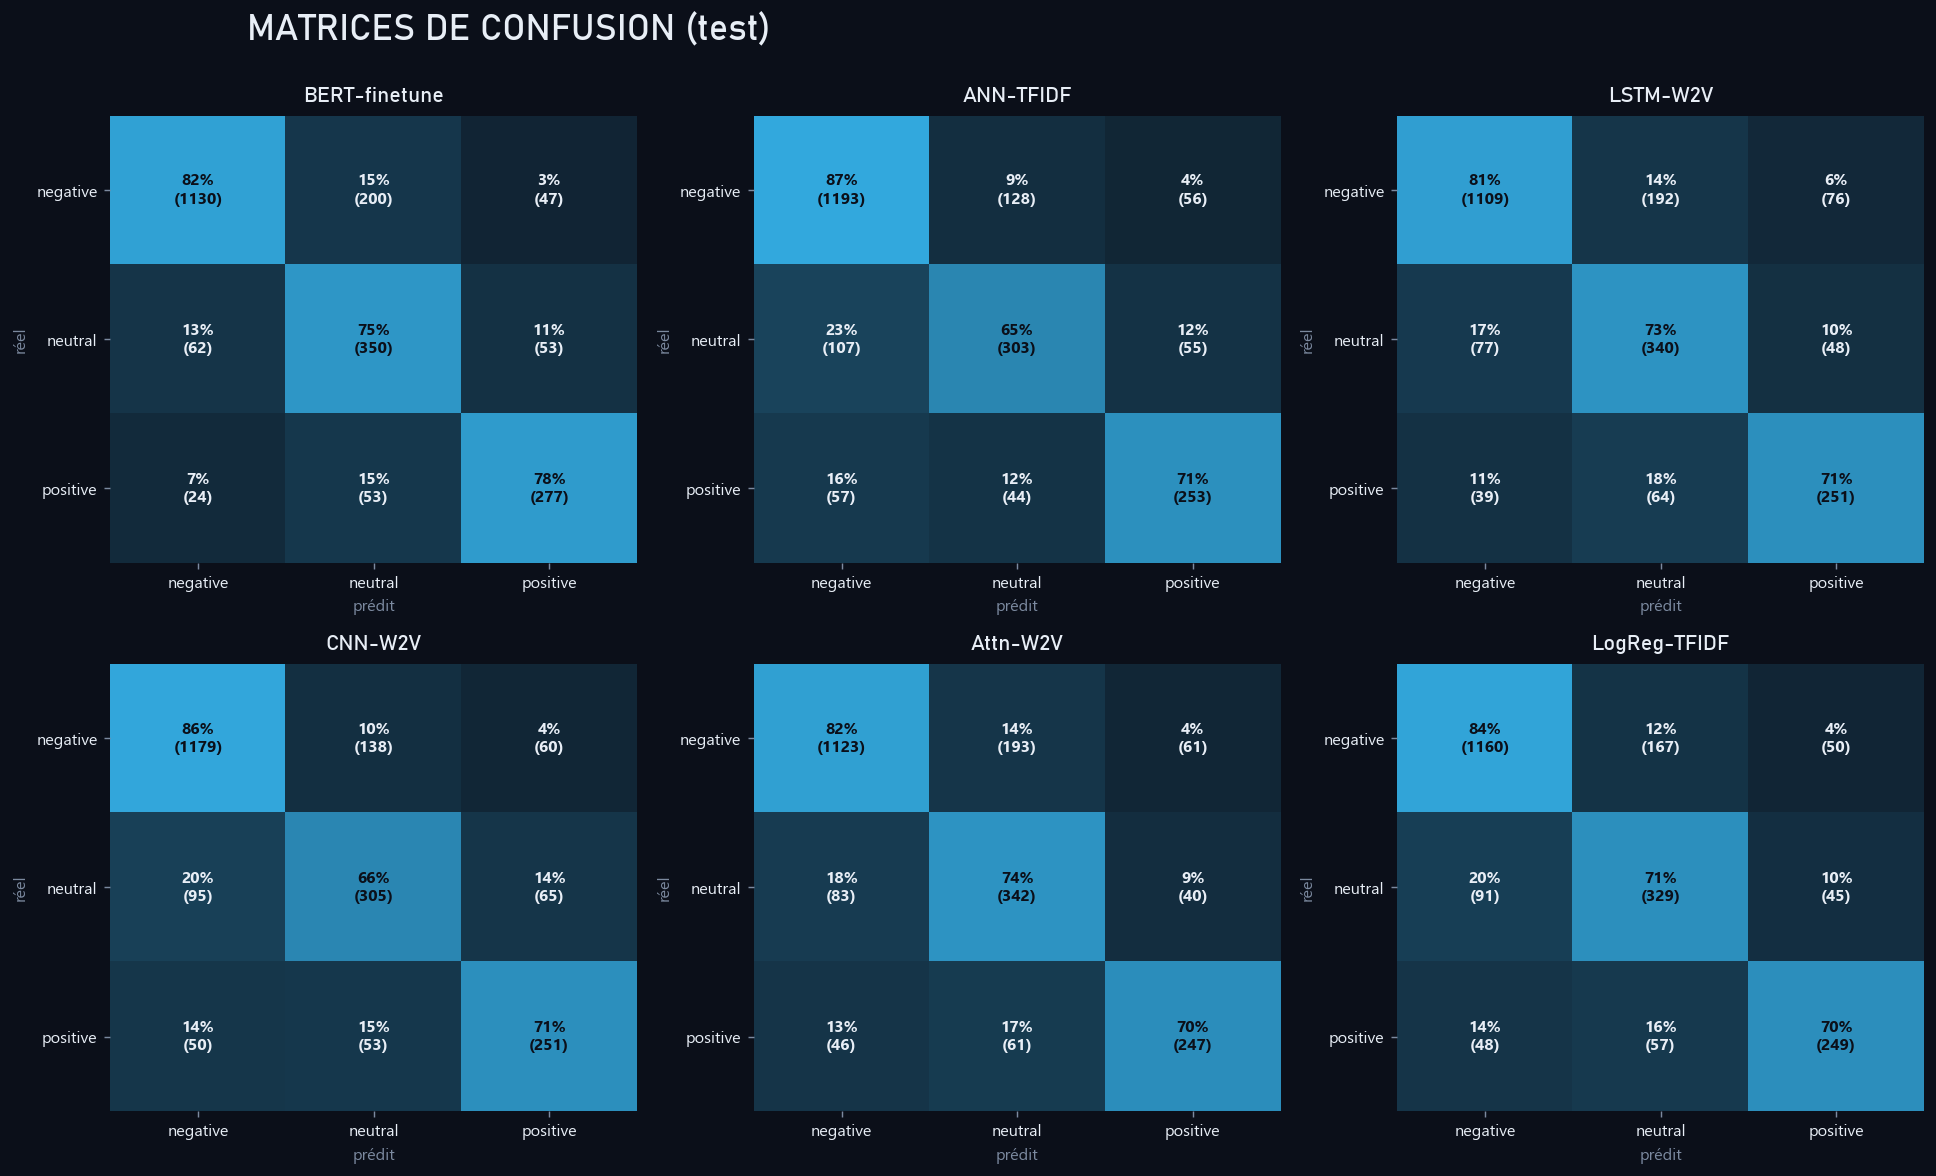

In [4]:
def plot_cm(ax, y, p, title):
    cm=confusion_matrix(y,p,labels=[0,1,2]); cmn=cm/cm.sum(1,keepdims=True)
    im=ax.imshow(cmn, cmap=vz._cmap('#10202E', vz.CYAN,'cm'), vmin=0, vmax=1, aspect='auto')
    for i in range(3):
        for j in range(3):
            ax.text(j,i,f"{cmn[i,j]*100:.0f}%\n({cm[i,j]})",ha='center',va='center',
                    color=('#0B0F19' if cmn[i,j]>0.6 else vz.TEXT),fontsize=9,fontweight='bold')
    ax.set_xticks(range(3)); ax.set_xticklabels(ORDER,fontsize=9,color=vz.TEXT)
    ax.set_yticks(range(3)); ax.set_yticklabels(ORDER,fontsize=9,color=vz.TEXT)
    ax.set_xlabel('prédit',color=vz.MUTED,fontsize=9); ax.set_ylabel('réel',color=vz.MUTED,fontsize=9)
    ax.set_title(title,color=vz.TEXT,fontfamily=vz.TITLE_FONT,fontsize=12,pad=8); ax.grid(False)

show=["BERT-finetune","ANN-TFIDF","LSTM-W2V","CNN-W2V","Attn-W2V","LogReg-TFIDF"]
show=[s for s in show if s in preds]
fig,axes=plt.subplots(2,3,figsize=(15,9))
for ax,name in zip(axes.ravel(),show): plot_cm(ax,yte,preds[name],name)
for ax in axes.ravel()[len(show):]: ax.axis('off')
fig.suptitle("MATRICES DE CONFUSION (test)",x=0.13,ha='left',color=vz.TEXT,
             fontfamily=vz.TITLE_FONT,fontsize=20,fontweight='bold',y=1.0)
plt.tight_layout(); vz.savefig(fig,FIG/"lot4_confusion.png"); plt.show()

**Lecture :** la diagonale est forte pour le négatif (classe majoritaire). Les confusions
dominantes sont **neutre ↔ négatif** : beaucoup de tweets neutres sont lus comme négatifs (le
contexte aérien est globalement négatif). BERT réduit le plus ces fuites.

## 3. Analyse d'erreurs — le neutre et l'ironie
On inspecte les tweets **mal classés par le meilleur modèle** (DistilBERT), en se concentrant sur
le **neutre** et les cas **ironiques/ambigus**.

In [5]:
best="BERT-finetune" if "BERT-finetune" in preds else "ANN-TFIDF"
pb=preds[best]
err=test.copy(); err["pred"]=[id2label[str(x)] for x in pb]; err["vrai"]=err["airline_sentiment"]
err=err[err["label"]!=pb]
print(f"Erreurs de {best} : {len(err)}/{len(test)} ({len(err)/len(test)*100:.1f}%)")
# Repartition des confusions
print("\nConfusions (vrai -> prédit) :")
print(err.groupby(["vrai","pred"]).size().sort_values(ascending=False).head(6))

Erreurs de BERT-finetune : 439/2196 (20.0%)

Confusions (vrai -> prédit) :
vrai      pred    
negative  neutral     200
neutral   negative     62
positive  neutral      53
neutral   positive     53
negative  positive     47
positive  negative     24
dtype: int64


In [6]:
# Exemples de neutres mal classes
ex=err[err["vrai"]=="neutral"][["text","vrai","pred"]].head(6)
for _,r in ex.iterrows():
    print(f"[vrai={r['vrai']} | prédit={r['pred']}]  {r['text'][:120]}")
print()
# Exemples potentiellement ironiques (positif predit negatif ou inverse)
iro=err[((err.vrai=='positive')&(err.pred=='negative'))|((err.vrai=='negative')&(err.pred=='positive'))]
print("Cas ironiques/ambigus (positif<->négatif) :", len(iro))
for _,r in iro.head(5).iterrows():
    print(f"[vrai={r['vrai']} | prédit={r['pred']}]  {r['text'][:120]}")

[vrai=neutral | prédit=positive]  @JetBlue Oh I will. #Disney bound. #workhard #playsoon
[vrai=neutral | prédit=negative]  @AmericanAir checking into a flight on your website is about as easy as asking a bear to shit in a toilet #justsaying
[vrai=neutral | prédit=positive]  @SouthwestAir will do! #heart #flying
[vrai=neutral | prédit=negative]  @JetBlue real shit my nigga north don't play around!
[vrai=neutral | prédit=positive]  @SouthwestAir OMG OMG OMG !!! I JUST DID!!
[vrai=neutral | prédit=positive]  @SouthwestAir Don't worry, you will! :-)

Cas ironiques/ambigus (positif<->négatif) : 71
[vrai=negative | prédit=positive]  @VirginAmerica spending my birthday night with you, DAL-DCA. Get me home!
[vrai=positive | prédit=negative]  @USAirways your pple did a great job w the madness however some of your systems need help. I appreciate the hard work &a
[vrai=negative | prédit=positive]  @SouthwestAir Kudos to bag handler at DTW gate 21 at 7:10 pm. Ran to keep bags from hitting ground i

**Lecture :** beaucoup d'erreurs **neutre→négatif** sont des tweets factuels/questions perçus
négativement. Les rares confusions **positif↔négatif** sont souvent **ironiques** ou contiennent une
négation complexe (« not bad », sarcasme) — limite intrinsèque même pour BERT.

## 4. Interprétabilité (1) — mots les plus influents (TF-IDF + LogReg)
Les coefficients de la régression logistique donnent les mots qui **poussent** vers chaque classe.

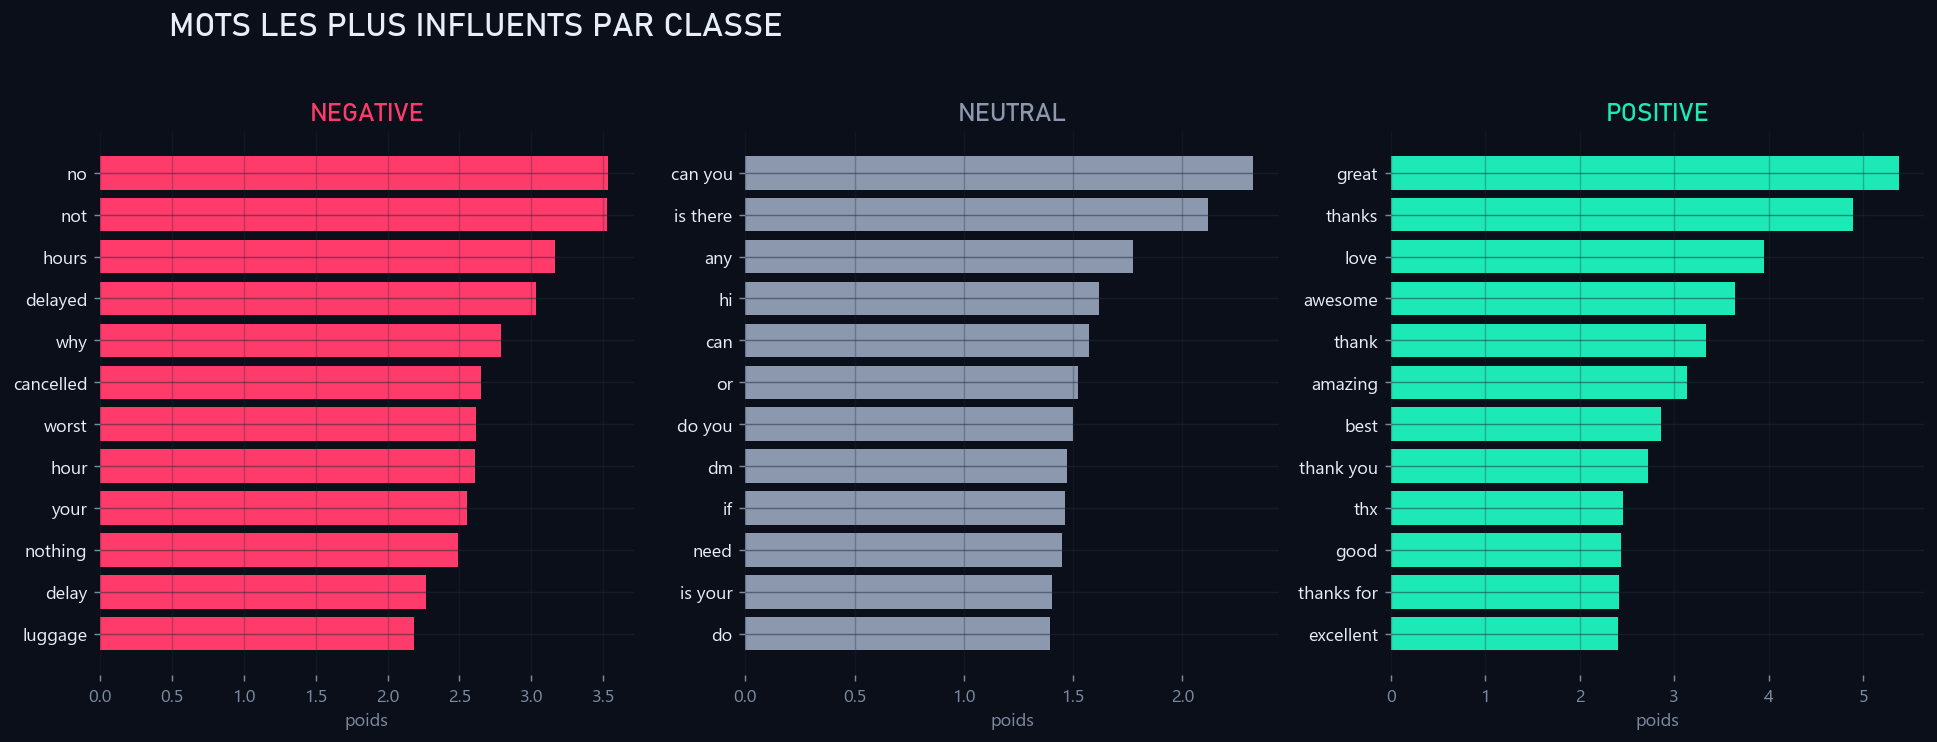

In [7]:
feats=np.array(vec.get_feature_names_out())
fig,axes=plt.subplots(1,3,figsize=(15,5.5))
colors={"negative":vz.NEG,"neutral":vz.NEU,"positive":vz.POS}
for ax,(cid,cname) in zip(axes,enumerate(ORDER)):
    top=np.argsort(logreg.coef_[cid])[-12:]
    vals=logreg.coef_[cid][top]
    ax.barh(range(len(top)),vals,color=colors[cname])
    ax.set_yticks(range(len(top))); ax.set_yticklabels(feats[top],color=vz.TEXT,fontsize=10)
    ax.set_title(cname.upper(),color=colors[cname],fontfamily=vz.TITLE_FONT,fontsize=14)
    ax.set_xlabel("poids",color=vz.MUTED); ax.grid(axis='x',alpha=0.3)
fig.suptitle("MOTS LES PLUS INFLUENTS PAR CLASSE",x=0.09,ha='left',color=vz.TEXT,
             fontfamily=vz.TITLE_FONT,fontsize=18,fontweight='bold',y=1.03)
plt.tight_layout(); vz.savefig(fig,FIG/"lot4_mots_influents.png"); plt.show()

**Lecture :** cohérent et lisible — *worst, hours, hold, delayed* (négatif) ; *thanks, great, awesome, love* (positif) ; le neutre capte des mots factuels (*flight, fleet, dm, help*).

## 5. Interprétabilité (2) — poids d'attention (BiLSTM+Attention)
On recharge le modèle d'attention du Lot 3 et on visualise **sur quels mots** il se concentre.

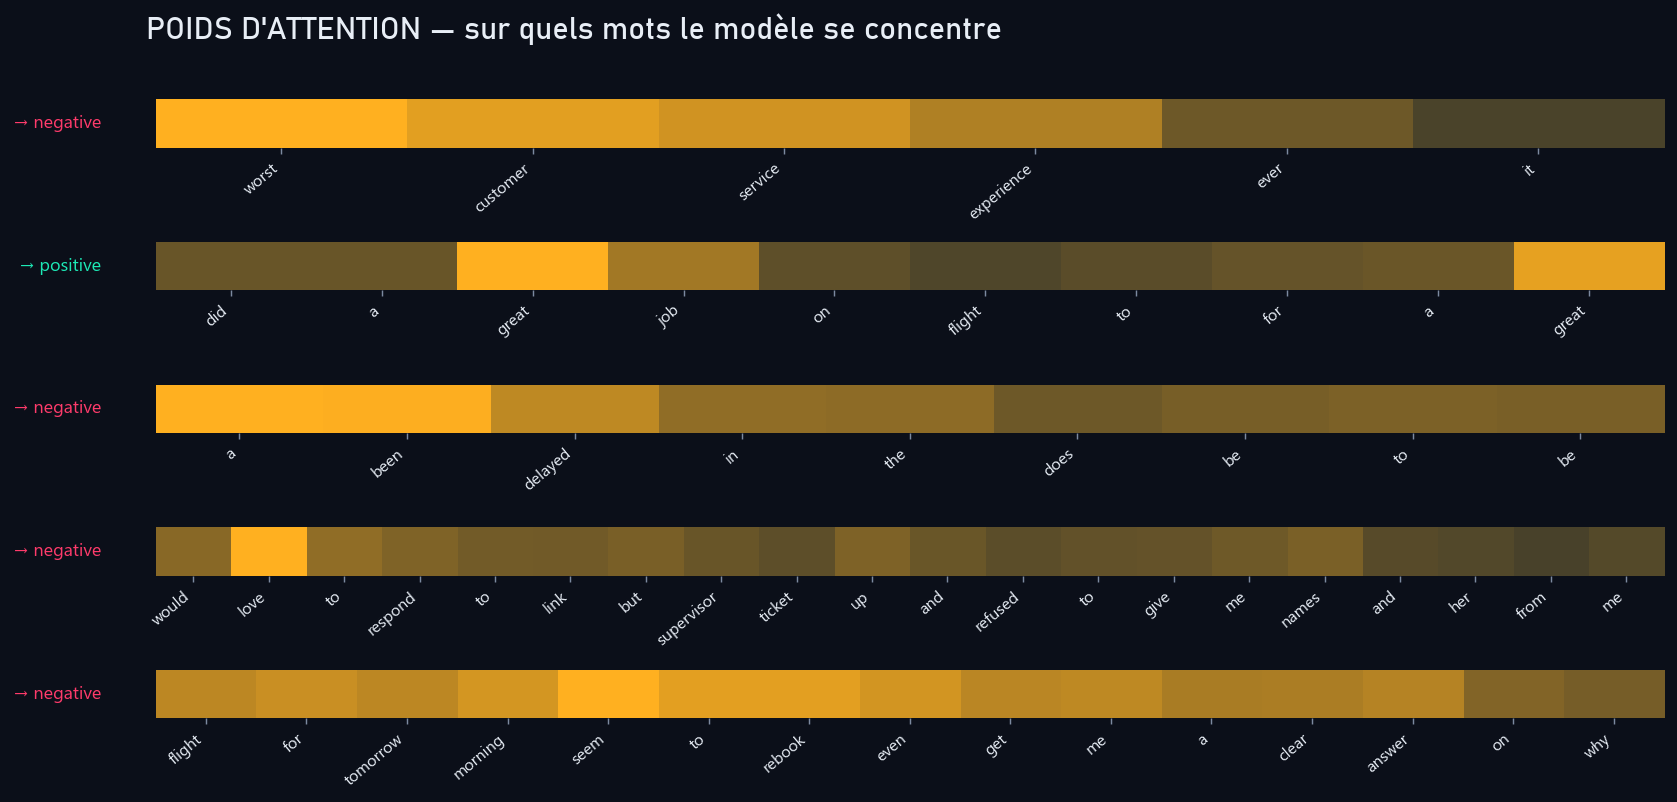

In [8]:
import torch
import dl_models as M, seq_utils as S
emb,w2i,pad=S.load_w2v(ART)
attn=M.AttnBiLSTM(emb,pad); attn.load_state_dict(torch.load(ART/"attn_w2v_state.pt")); attn.eval()

def attn_weights(text):
    toks=[w for w in str(text).split() if w in w2i][:40]
    if not toks: return [],[],None
    seq=S.texts_to_sequences([text],w2i,pad,40)
    with torch.no_grad():
        logits,w=attn(torch.tensor(seq),return_attn=True)
    pred=ORDER[int(logits.argmax(1))]
    return toks,w[0,:len(toks)].numpy(),pred

# Quelques tweets test parlants
samples=[]
for kw in ["worst","thanks","delayed","love","cancelled"]:
    m=test[test["text_clean"].str.contains(rf"\b{kw}\b",na=False)]
    if len(m): samples.append(m.iloc[0]["text"])
samples=samples[:5]

fig,axes=plt.subplots(len(samples),1,figsize=(13,1.0*len(samples)+1))
if len(samples)==1: axes=[axes]
for ax,txt in zip(axes,samples):
    toks,w,pred=attn_weights(txt)
    if not toks: ax.axis('off'); continue
    w=w/ (w.max()+1e-9)
    ax.imshow(w[None,:],cmap=vz._cmap('#10202E',vz.AMBER,'a'),aspect='auto',vmin=0,vmax=1)
    ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks,rotation=40,ha='right',fontsize=9,color=vz.TEXT)
    ax.set_yticks([]); ax.set_ylabel(f"→ {pred}",color=vz.POS if pred=='positive' else (vz.NEG if pred=='negative' else vz.NEU),
                                     fontsize=10,rotation=0,ha='right',va='center',labelpad=30)
    ax.grid(False)
fig.suptitle("POIDS D'ATTENTION — sur quels mots le modèle se concentre",x=0.09,ha='left',
             color=vz.TEXT,fontfamily=vz.TITLE_FONT,fontsize=17,fontweight='bold',y=1.02)
plt.tight_layout(); vz.savefig(fig,FIG/"lot4_attention.png"); plt.show()

**Lecture :** l'attention se pose sur les mots porteurs de sentiment (*worst, thanks, delayed, love*) et ignore les mots vides — preuve que le modèle a appris **où regarder**, pas seulement à prédire.

## 6. Performance vs complexité vs coût

In [9]:
cost=pd.DataFrame([
 {"modèle":"LogReg-TFIDF","params":"~37k","entraînement":"~2 s","atout":"explicable, instantané"},
 {"modèle":"ANN-TFIDF","params":"~3.2M","entraînement":"~1-2 min","atout":"simple, solide"},
 {"modèle":"CNN-W2V","params":"~0.4M","entraînement":"~1 min","atout":"léger, n-grammes"},
 {"modèle":"LSTM-W2V","params":"~0.6M","entraînement":"~1 min","atout":"séquentiel"},
 {"modèle":"Attn-W2V","params":"~0.6M","entraînement":"~1 min","atout":"interprétable"},
 {"modèle":"BERT-finetune","params":"~66M","entraînement":"~40 min (CPU)","atout":"meilleur score"},
]).set_index("modèle")
cost

,params,entraînement,atout
modèle,,,
LogReg-TFIDF,~37k,~2 s,"explicable, instantané"
ANN-TFIDF,~3.2M,~1-2 min,"simple, solide"
CNN-W2V,~0.4M,~1 min,"léger, n-grammes"
LSTM-W2V,~0.6M,~1 min,séquentiel
Attn-W2V,~0.6M,~1 min,interprétable
BERT-finetune,~66M,~40 min (CPU),meilleur score


**Arbitrage métier :** pour de l'**alerte temps réel à grande échelle**, **TF-IDF + LogReg/ANN**
offre un rapport qualité/coût imbattable et reste explicable. Pour la **priorisation fine** (réduire
les faux négatifs sur le neutre/positif), **DistilBERT fine-tuné** vaut son coût de calcul.

## 7. Synthèse du Lot 4

✅ **Évaluation test complète** : tableau de synthèse (accuracy, F1-macro, F1 par classe) + matrices de confusion.

✅ **Analyse d'erreurs** : la classe **neutre** est le point faible (confusion neutre↔négatif) ; les
erreurs positif↔négatif sont surtout **ironiques/sarcastiques**.

✅ **Interprétabilité** : mots influents (TF-IDF) **et** poids d'attention → la « boîte noire » est ouverte.

✅ **Coût** : arbitrage clair perf/complexité/coût selon l'usage métier.

➡️ **Dernière étape : Lot 5 — déploiement (application Streamlit de démonstration).**